In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
#!unzip '/content/drive/MyDrive/Brain_Tumor_Dataset.zip' -d dataset

In [7]:
import os

for root, dirs, files in os.walk('dataset'):
    print(root)

dataset
dataset/Brain Tumor Data Set
dataset/Brain Tumor Data Set/no
dataset/Brain Tumor Data Set/yes


In [8]:
import os

for folder in ['yes', 'no']:
    path = f'dataset/Brain Tumor Data Set/{folder}'
    count = len(os.listdir(path))
    print(f"Folder '{folder}': {count} images")

Folder 'yes': 2513 images
Folder 'no': 2087 images


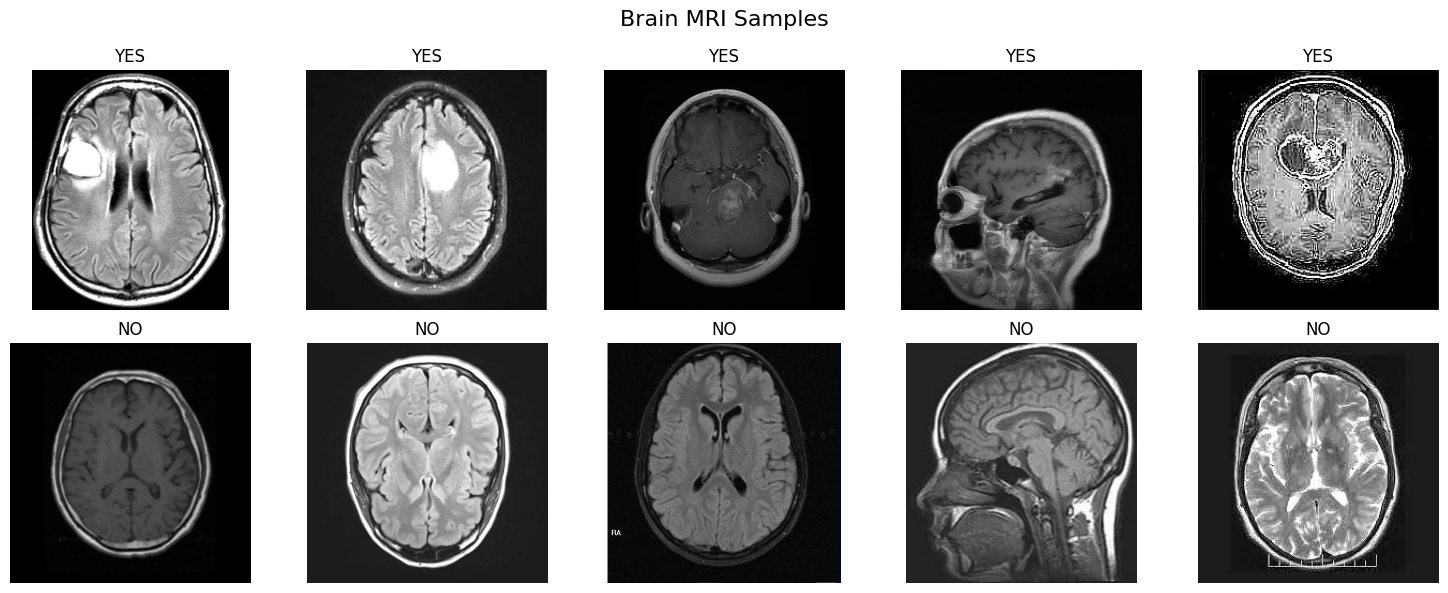

In [9]:
import cv2
import matplotlib.pyplot as plt
import os
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Brain MRI Samples', fontsize=16)

for i, category in enumerate(['yes', 'no']):
    path = f'dataset/Brain Tumor Data Set/{category}'
    images = os.listdir(path)
    samples = random.sample(images, 5)

    for j, img_name in enumerate(samples):
        img = cv2.imread(os.path.join(path, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # fix colors
        axes[i][j].imshow(img)
        axes[i][j].set_title(category.upper())
        axes[i][j].axis('off')

plt.tight_layout()
plt.show()

In [10]:
import numpy as np

data = []
labels = []
IMG_SIZE = 128

for category in ['yes', 'no']:
    path = f'dataset/Brain Tumor Data Set/{category}'
    label = 1 if category == 'yes' else 0  # yes=1, no=0

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)

        if img is None:  # skip corrupted images
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        data.append(img)
        labels.append(label)

# convert to numpy arrays
data = np.array(data) / 255.0   # normalize (0-255 → 0-1)
labels = np.array(labels)

print(f"Total images loaded: {len(data)}")
print(f"Data shape: {data.shape}")
print(f"Tumor (1): {sum(labels==1)}, Normal (0): {sum(labels==0)}")

Total images loaded: 4600
Data shape: (4600, 128, 128, 3)
Tumor (1): 2513, Normal (0): 2087


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, labels,
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42     # fixed seed so results are reproducible
)

print(f"Training images: {len(X_train)}")
print(f"Testing images:  {len(X_test)}")

Training images: 3680
Testing images:  920


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Final layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),          # prevents overfitting
    Dense(1, activation='sigmoid')   # output: tumor or not
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.7120 - loss: 0.5664 - val_accuracy: 0.8109 - val_loss: 0.4010
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8375 - loss: 0.3685 - val_accuracy: 0.8641 - val_loss: 0.3504
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8978 - loss: 0.2546 - val_accuracy: 0.8978 - val_loss: 0.2479
Epoch 4/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9334 - loss: 0.1716 - val_accuracy: 0.9304 - val_loss: 0.1742
Epoch 5/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9582 - loss: 0.1144 - val_accuracy: 0.9380 - val_loss: 0.1577
Epoch 6/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9715 - loss: 0.0813 - val_accuracy: 0.9598 - val_loss: 0.1212
Epoch 7/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9812 - loss: 0.0603 - val_accuracy: 0.9533 - val_loss: 0.1423
Epoch 8/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9821 - loss: 0.0476 - val_acc

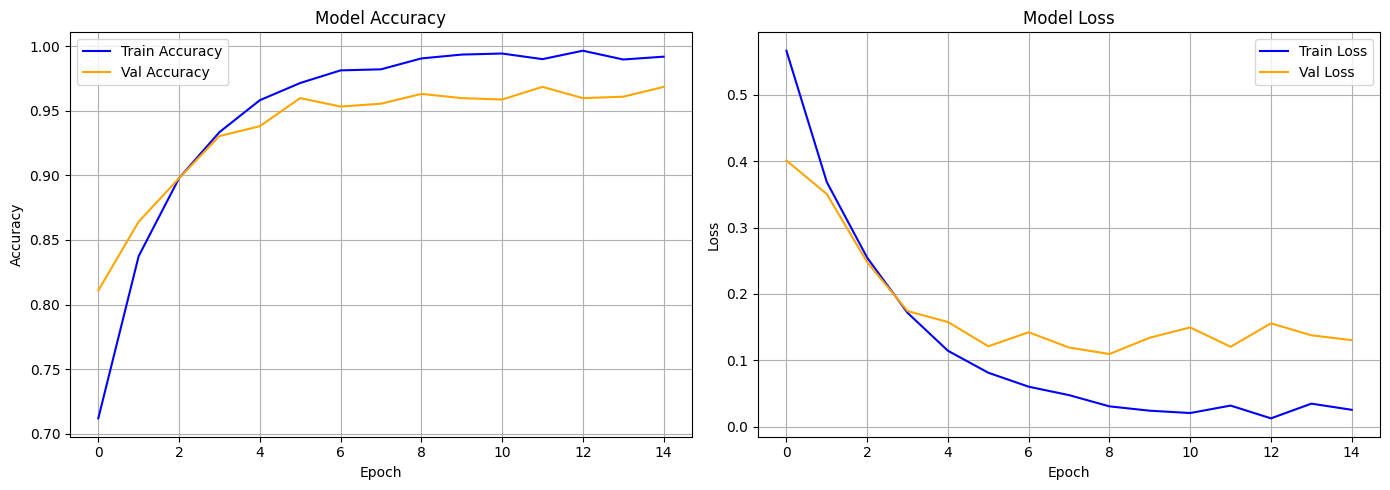

In [14]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       399
           1       0.97      0.97      0.97       521

    accuracy                           0.97       920
   macro avg       0.97      0.97      0.97       920
weighted avg       0.97      0.97      0.97       920



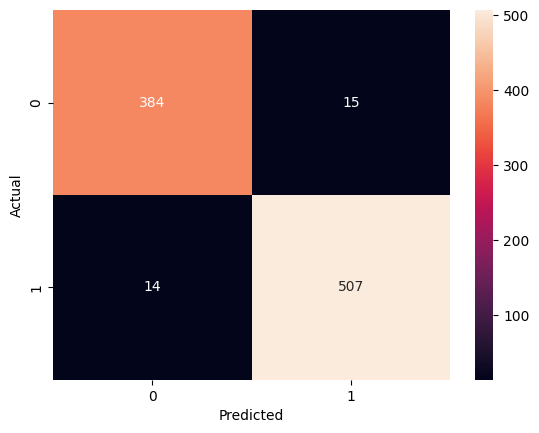

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Saving Cancer (983).jpg to Cancer (983).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


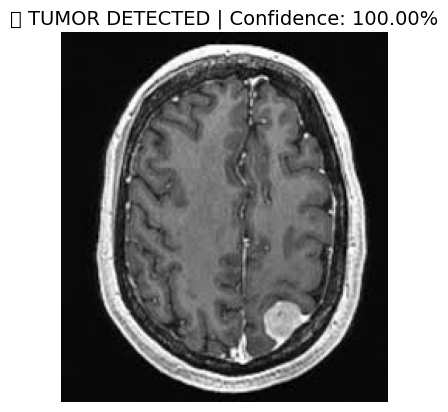

Result: 🔴 TUMOR DETECTED
Confidence: 100.00%


In [17]:
from google.colab import files
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Upload any image from your computer
uploaded = files.upload()

# Get the filename
img_path = list(uploaded.keys())[0]

# Predict
def predict_tumor(img_path):
    img = cv2.imread(img_path)
    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img, (128, 128))
    img_normalized = img_resized / 255.0
    img_input = np.reshape(img_normalized, (1, 128, 128, 3))

    pred = model.predict(img_input)[0][0]
    confidence = pred if pred > 0.5 else 1 - pred
    result = "🔴 TUMOR DETECTED" if pred > 0.5 else "🟢 NO TUMOR"

    # Show image with result
    plt.imshow(img_display)
    plt.title(f"{result} | Confidence: {confidence*100:.2f}%", fontsize=14)
    plt.axis('off')
    plt.show()

    print(f"Result: {result}")
    print(f"Confidence: {confidence*100:.2f}%")

predict_tumor(img_path)

In [18]:
# Save the model
model.save('brain_tumor_detector.h5')
print("Model saved successfully!")

Model saved successfully!


In [19]:
from google.colab import files
files.download('brain_tumor_detector.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>